In [1]:
import pandas as pd
from pysyncon import Dataprep, Synth
from pysyncon.utils import PlaceboTest
import numpy as np
from statsmodels.formula.api import ols

In [2]:
#Загрузка данных
df = pd.read_excel( "C:\\Users\\mtaip\\Downloads\\Fixed investments.xlsx ")
df.head()

,year,CAPEX,Industry
0,2000,31.0991,Network
1,2001,45.0827,Network
2,2002,59.8975,Network
3,2003,104.6227,Network
4,2004,155.6929,Network


In [33]:
dataprep = Dataprep(
    foo=df,
    predictors=["CAPEX"],
    predictors_op="mean",
    time_predictors_prior=range(2000,2014),
   
    dependent="CAPEX",
    unit_variable="Industry",
    time_variable="year",
    treatment_identifier="Network",
    controls_identifier=[
         "Food", "retail","metallurgy","healthcare","real estate","agriculture","finance","paper","building","mining","science"
    ],
    time_optimize_ssr=range(2000, 2014),
)
print(dataprep)

Dataprep
Treated unit: Network
Dependent variable: CAPEX
Control units: Food, retail, metallurgy, healthcare, real estate, agriculture, finance, paper, building, mining, science
Time range in data: 2000 - 2023
Time range for loss minimization: range(2000, 2014)
Time range for predictors: range(2000, 2014)
Predictors: CAPEX



In [34]:

synth = Synth()
#Настройка синтетического контроля
synth.fit(dataprep=dataprep1, optim_method="BFGS", optim_initial="ols")
#Полученные веса
synth.weights(threshold=0.01)

Food           0.104
retail         0.069
metallurgy     0.091
healthcare     0.102
real estate    0.053
agriculture    0.063
finance        0.120
paper          0.141
building       0.068
mining         0.053
science        0.135
Name: weights, dtype: float64

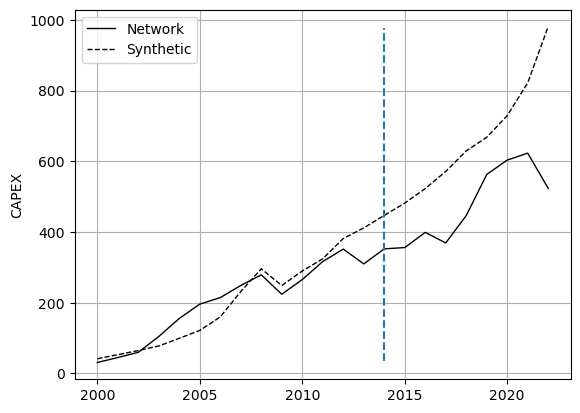

In [35]:
#Графики инвестиций в отрасль связи и синтетического контроля
synth.path_plot(time_period=range(2000, 2023), treatment_time=2014)

In [36]:
#плацебо-тест
placebo_test = PlaceboTest()
placebo_test.fit(
    dataprep=dataprep,
    scm=synth,
    scm_options={"optim_method":"BFGS", "optim_initial":"ols"   },
)

(1/11) Completed placebo test for real estate.
(2/11) Completed placebo test for mining.
(3/11) Completed placebo test for paper.
(4/11) Completed placebo test for retail.
(5/11) Completed placebo test for healthcare.
(6/11) Completed placebo test for finance.
(7/11) Completed placebo test for Food.
(8/11) Completed placebo test for agriculture.
(9/11) Completed placebo test for building.
(10/11) Completed placebo test for metallurgy.
(11/11) Completed placebo test for science.
Calculating treated unit gaps.
Done.


In [37]:
#Тест Фишера на отсутствие эффекта сетевого нейтралитета
placebo_test.pvalue(treatment_time=2014)

0.16666666666666666

In [39]:
dataprep = Dataprep(
    foo=df,
    predictors=["CAPEX"],
    predictors_op="mean",
    time_predictors_prior=range(2000,2015),
   
    dependent="CAPEX",
    unit_variable="Industry",
    time_variable="year",
    treatment_identifier="Network",
    controls_identifier=[
         "Food", "retail","metallurgy","healthcare","real estate","agriculture","finance","paper","building","mining","science"
    ],
    time_optimize_ssr=range(2000, 2015),
)
print(dataprep)

Dataprep
Treated unit: Network
Dependent variable: CAPEX
Control units: Food, retail, metallurgy, healthcare, real estate, agriculture, finance, paper, building, mining, science
Time range in data: 2000 - 2023
Time range for loss minimization: range(2000, 2015)
Time range for predictors: range(2000, 2015)
Predictors: CAPEX



In [40]:

synth = Synth()
#Настройка синтетического контроля
synth.fit(dataprep=dataprep, optim_method="BFGS", optim_initial="ols")
#Полученные веса
synth.weights(threshold=0.01)

Food           0.106
retail         0.064
metallurgy     0.092
healthcare     0.104
real estate    0.051
agriculture    0.060
finance        0.123
paper          0.147
building       0.065
mining         0.051
science        0.138
Name: weights, dtype: float64

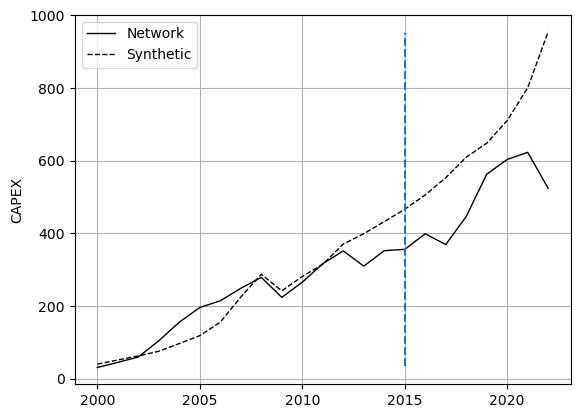

In [41]:
#Графики инвестиций в отрасль связи и синтетического контроля
synth.path_plot(time_period=range(2000, 2023), treatment_time=2015)

In [42]:
#плацебо-тест
placebo_test = PlaceboTest()
placebo_test.fit(
    dataprep=dataprep,
    scm=synth,
    scm_options={"optim_method":"BFGS", "optim_initial":"ols"   },
)

(1/11) Completed placebo test for healthcare.
(2/11) Completed placebo test for Food.
(3/11) Completed placebo test for metallurgy.
(4/11) Completed placebo test for building.
(5/11) Completed placebo test for agriculture.
(6/11) Completed placebo test for retail.
(7/11) Completed placebo test for mining.
(8/11) Completed placebo test for science.
(9/11) Completed placebo test for real estate.
(10/11) Completed placebo test for finance.
(11/11) Completed placebo test for paper.
Calculating treated unit gaps.
Done.


In [44]:
placebo_test.pvalue(treatment_time=2015)

0.16666666666666666

In [45]:
dataprep = Dataprep(
    foo=df,
    predictors=["CAPEX"],
    predictors_op="mean",
    time_predictors_prior=range(2000,2016),
   
    dependent="CAPEX",
    unit_variable="Industry",
    time_variable="year",
    treatment_identifier="Network",
    controls_identifier=[
         "Food", "retail","metallurgy","healthcare","real estate","agriculture","finance","paper","building","mining","science"
    ],
    time_optimize_ssr=range(2000, 2016),
)
print(dataprep)

Dataprep
Treated unit: Network
Dependent variable: CAPEX
Control units: Food, retail, metallurgy, healthcare, real estate, agriculture, finance, paper, building, mining, science
Time range in data: 2000 - 2023
Time range for loss minimization: range(2000, 2016)
Time range for predictors: range(2000, 2016)
Predictors: CAPEX



In [46]:
synth = Synth()
#Настройка синтетического контроля
synth.fit(dataprep=dataprep, optim_method="BFGS", optim_initial="ols")
#Полученные веса
synth.weights(threshold=0.01)

Food           0.107
retail         0.060
metallurgy     0.094
healthcare     0.107
real estate    0.048
agriculture    0.057
finance        0.125
paper          0.151
building       0.064
mining         0.048
science        0.139
Name: weights, dtype: float64

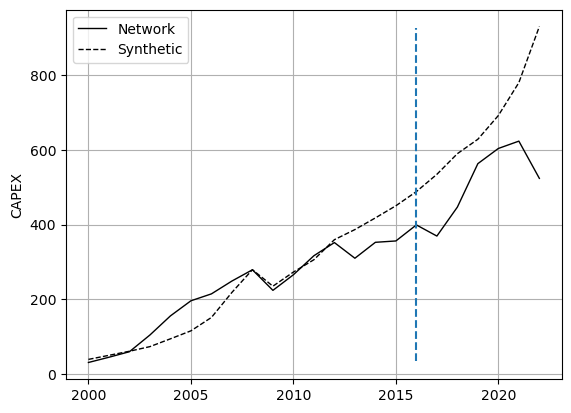

In [47]:
#Графики инвестиций в отрасль связи и синтетического контроля
synth.path_plot(time_period=range(2000, 2023), treatment_time=2016)

In [48]:
#плацебо-тест
placebo_test = PlaceboTest()
placebo_test.fit(
    dataprep=dataprep,
    scm=synth,
    scm_options={"optim_method":"BFGS", "optim_initial":"ols"   },
)

(1/11) Completed placebo test for retail.
(2/11) Completed placebo test for healthcare.
(3/11) Completed placebo test for metallurgy.
(4/11) Completed placebo test for Food.
(5/11) Completed placebo test for real estate.
(6/11) Completed placebo test for paper.
(7/11) Completed placebo test for finance.
(8/11) Completed placebo test for building.
(9/11) Completed placebo test for agriculture.
(10/11) Completed placebo test for mining.
(11/11) Completed placebo test for science.
Calculating treated unit gaps.
Done.


In [49]:
placebo_test.pvalue(treatment_time=2016)

0.16666666666666666

In [50]:
dataprep = Dataprep(
    foo=df,
    predictors=["CAPEX"],
    predictors_op="mean",
    time_predictors_prior=range(2000,2017),
   
    dependent="CAPEX",
    unit_variable="Industry",
    time_variable="year",
    treatment_identifier="Network",
    controls_identifier=[
         "Food", "retail","metallurgy","healthcare","real estate","agriculture","finance","paper","building","mining","science"
    ],
    time_optimize_ssr=range(2000, 2017),
)
print(dataprep)

Dataprep
Treated unit: Network
Dependent variable: CAPEX
Control units: Food, retail, metallurgy, healthcare, real estate, agriculture, finance, paper, building, mining, science
Time range in data: 2000 - 2023
Time range for loss minimization: range(2000, 2017)
Time range for predictors: range(2000, 2017)
Predictors: CAPEX



In [51]:
synth = Synth()
#Настройка синтетического контроля
synth.fit(dataprep=dataprep, optim_method="BFGS", optim_initial="ols")
#Полученные веса
synth.weights(threshold=0.01)

Food           0.109
retail         0.056
metallurgy     0.094
healthcare     0.110
real estate    0.046
agriculture    0.054
finance        0.126
paper          0.154
building       0.064
mining         0.046
science        0.140
Name: weights, dtype: float64

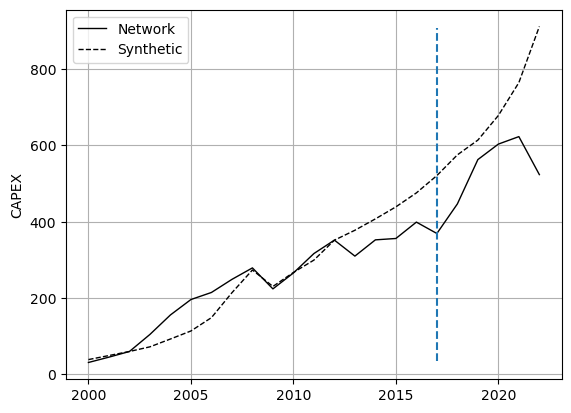

In [52]:
#Графики инвестиций в отрасль связи и синтетического контроля
synth.path_plot(time_period=range(2000, 2023), treatment_time=2017)

In [53]:
#плацебо-тест
placebo_test = PlaceboTest()
placebo_test.fit(
    dataprep=dataprep,
    scm=synth,
    scm_options={"optim_method":"BFGS", "optim_initial":"ols"   },
)

(1/11) Completed placebo test for Food.
(2/11) Completed placebo test for retail.
(3/11) Completed placebo test for metallurgy.
(4/11) Completed placebo test for real estate.
(5/11) Completed placebo test for agriculture.
(6/11) Completed placebo test for building.
(7/11) Completed placebo test for finance.
(8/11) Completed placebo test for mining.
(9/11) Completed placebo test for paper.
(10/11) Completed placebo test for healthcare.
(11/11) Completed placebo test for science.
Calculating treated unit gaps.
Done.


In [54]:
placebo_test.pvalue(treatment_time=2017)

0.16666666666666666

In [55]:
dataprep = Dataprep(
    foo=df,
    predictors=["CAPEX"],
    predictors_op="mean",
    time_predictors_prior=range(2000,2018),
   
    dependent="CAPEX",
    unit_variable="Industry",
    time_variable="year",
    treatment_identifier="Network",
    controls_identifier=[
         "Food", "retail","metallurgy","healthcare","real estate","agriculture","finance","paper","building","mining","science"
    ],
    time_optimize_ssr=range(2000, 2018),
)
print(dataprep)

Dataprep
Treated unit: Network
Dependent variable: CAPEX
Control units: Food, retail, metallurgy, healthcare, real estate, agriculture, finance, paper, building, mining, science
Time range in data: 2000 - 2023
Time range for loss minimization: range(2000, 2018)
Time range for predictors: range(2000, 2018)
Predictors: CAPEX



In [56]:
synth = Synth()
#Настройка синтетического контроля
synth.fit(dataprep=dataprep, optim_method="BFGS", optim_initial="ols")
#Полученные веса
synth.weights(threshold=0.01)

Food           0.111
retail         0.051
metallurgy     0.097
healthcare     0.114
real estate    0.044
agriculture    0.048
finance        0.127
paper          0.160
building       0.062
mining         0.044
science        0.144
Name: weights, dtype: float64

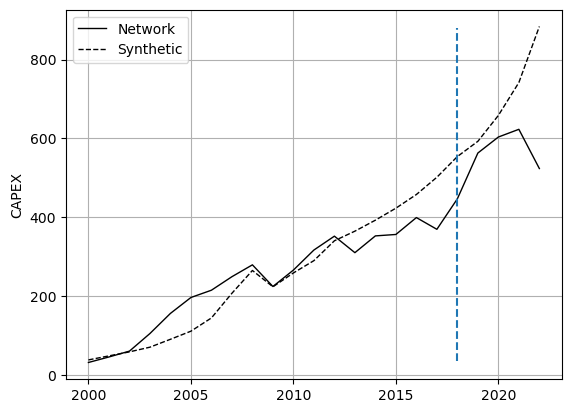

In [57]:
#Графики инвестиций в отрасль связи и синтетического контроля
synth.path_plot(time_period=range(2000, 2023), treatment_time=2018)

In [58]:
#плацебо-тест
placebo_test = PlaceboTest()
placebo_test.fit(
    dataprep=dataprep,
    scm=synth,
    scm_options={"optim_method":"BFGS", "optim_initial":"ols"   },
)

(1/11) Completed placebo test for healthcare.
(2/11) Completed placebo test for metallurgy.
(3/11) Completed placebo test for finance.
(4/11) Completed placebo test for science.
(5/11) Completed placebo test for building.
(6/11) Completed placebo test for agriculture.
(7/11) Completed placebo test for retail.
(8/11) Completed placebo test for Food.
(9/11) Completed placebo test for real estate.
(10/11) Completed placebo test for paper.
(11/11) Completed placebo test for mining.
Calculating treated unit gaps.
Done.


In [59]:
placebo_test.pvalue(treatment_time=2018)

0.16666666666666666